In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Environment ready!")

Matplotlib is building the font cache; this may take a moment.


Environment ready!


In [2]:
scores = pd.read_excel("../data/raw/breast_scores.xlsx")
qlq = pd.read_excel("../data/raw/breast_qlq_c30.xlsx")
cppo = pd.read_excel("../data/raw/breast_cppo.xlsx")

print("breast_scores:", scores.shape)
print("breast_qlq_c30:", qlq.shape)
print("breast_cppo:", cppo.shape)

breast_scores: (339, 13)
breast_qlq_c30: (339, 36)
breast_cppo: (219, 15)


In [2]:
import sys
print(sys.executable)

c:\Program Files\Python312\python.exe


In [3]:
print("========== breast_scores ==========")
print(scores.columns.tolist())

print("\n========== breast_qlq_c30 ==========")
print(qlq.columns.tolist())

print("\n========== breast_cppo ==========")
print(cppo.columns.tolist())

========== breast_scores ==========
['SURGERY', 'HE_BASELINE', 'PH_BASELINE', 'RO_BASELINE', 'EF_BASELINE', 'SO_BASELINE', 'COG_BASELINE', 'HE6', 'PH6', 'RO6', 'EF6', 'SO6', 'COG6']

========== breast_qlq_c30 ==========
['ID', 'HE_baseline', 'PH_baseline', 'RO_baseline', 'EF_baseline', 'COG_baseline', 'SO_baseline', 'FA_baseline', 'Nau_baseline', 'PA_baseline', 'DY_baseline', 'IN_baseline', 'AP_baseline', 'CO_baseline', 'DIA_baseline', 'FI_baseline', 'SYM_baseline', 'Overall_EORTC_baseline', 'HE_end', 'PH_end', 'RO_end', 'EF_end', 'COG_end', 'SO_end', 'FA_end', 'NA_end', 'PA_end', 'DY_end', 'IN_end', 'AP_end', 'CO_end', 'DIA_end', 'FI_end', 'SYM_end', 'Overall_EORTC_end', 'Surgery']

========== breast_cppo ==========
['Axillary_lymphadenectomy', 'Surgery', 'Health_status_end', 'Age', 'Educational_level', 'Chemotherapy_regimen', 'Radiotherapy', 'Occupational_status ', 'Children', 'TNM_stage', 'EORTC_baseline', 'ECOG', 'HER2', 'Marital_status', 'Perceived_risk_recurrence']


In [4]:
print("\n========== QLQ FIRST 5 ROWS ==========")
display(qlq.head())

print("\n========== CPPO FIRST 5 ROWS ==========")
display(cppo.head())


========== QLQ FIRST 5 ROWS ==========


,ID,HE_baseline,PH_baseline,RO_baseline,EF_baseline,COG_baseline,SO_baseline,FA_baseline,Nau_baseline,PA_baseline,DY_baseline,IN_baseline,AP_baseline,CO_baseline,DIA_baseline,FI_baseline,SYM_baseline,Overall_EORTC_baseline,HE_end,PH_end,RO_end,EF_end,COG_end,SO_end,FA_end,NA_end,PA_end,DY_end,IN_end,AP_end,CO_end,DIA_end,FI_end,SYM_end,Overall_EORTC_end,Surgery
0,8,58.3,73.3,83.3,58.3,83.3,66.7,55.6,0.0,16.7,33.3,66.7,66.7,33.3,0.0,33.3,34.0,62.46,83.3,100.0,100.0,91.7,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,87.22,BCS
1,14,83.3,100.0,100.0,91.7,100.0,100.0,22.2,0.0,0.0,0.0,33.3,0.0,0.0,33.3,0.0,9.9,83.93,83.3,100.0,100.0,100.0,100.0,100.0,33.3,0.0,0.0,0.0,33.3,0.0,0.0,33.3,0.0,11.1,84.07,BCS
2,22,66.7,80.0,66.7,91.7,83.3,100.0,33.3,0.0,0.0,0.0,0.0,33.3,33.3,33.3,33.3,18.5,74.16,0.0,66.7,0.0,66.7,100.0,33.3,100.0,16.7,0.0,0.0,66.7,100.0,0.0,100.0,33.3,46.3,29.01,Mastectomy
3,23,50.0,86.7,50.0,50.0,50.0,33.3,66.7,0.0,66.7,0.0,66.7,66.7,0.0,66.7,0.0,37.0,52.32,16.7,60.0,0.0,8.3,16.7,33.3,88.9,0.0,66.7,0.0,33.3,33.3,0.0,33.3,0.0,28.4,36.20,Mastectomy
4,25,83.3,86.7,100.0,100.0,100.0,100.0,44.4,0.0,0.0,0.0,66.7,66.7,0.0,0.0,0.0,19.8,80.30,50.0,86.7,66.7,100.0,100.0,83.3,44.4,0.0,16.7,0.0,33.3,66.7,0.0,0.0,0.0,17.9,66.48,Mastectomy



========== CPPO FIRST 5 ROWS ==========


,Axillary_lymphadenectomy,Surgery,Health_status_end,Age,Educational_level,Chemotherapy_regimen,Radiotherapy,Occupational_status,Children,TNM_stage,EORTC_baseline,ECOG,HER2,Marital_status,Perceived_risk_recurrence
0,No,BSC,83.3,60,Other,Taxane-based,Yes,Employed,2,II,62.46,0,Negative,Married/partnered,High
1,No,BSC,83.3,51,Other,Taxane-based,Yes,Not employed,> 2 children,I,83.93,0,Positive,Married/partnered,High
2,No,Mastectomy,0.0,46,Other,Taxane-based,Yes,Employed,2,II,74.16,0,Negative,Married/partnered,Very high
3,No,Mastectomy,16.7,43,Other,Taxane-based,No,Not employed,2,I,52.32,0,Positive,Married/partnered,High
4,No,Mastectomy,50.0,74,Secondary or higher education,Anthracycline-based,No,Not employed,2,I,80.30,0,Negative,Single,Very high


In [5]:
display(cppo.head(10))

,Axillary_lymphadenectomy,Surgery,Health_status_end,Age,Educational_level,Chemotherapy_regimen,Radiotherapy,Occupational_status,Children,TNM_stage,EORTC_baseline,ECOG,HER2,Marital_status,Perceived_risk_recurrence
0,No,BSC,83.3,60,Other,Taxane-based,Yes,Employed,2,II,62.46,0,Negative,Married/partnered,High
1,No,BSC,83.3,51,Other,Taxane-based,Yes,Not employed,> 2 children,I,83.93,0,Positive,Married/partnered,High
2,No,Mastectomy,0.0,46,Other,Taxane-based,Yes,Employed,2,II,74.16,0,Negative,Married/partnered,Very high
3,No,Mastectomy,16.7,43,Other,Taxane-based,No,Not employed,2,I,52.32,0,Positive,Married/partnered,High
4,No,Mastectomy,50.0,74,Secondary or higher education,Anthracycline-based,No,Not employed,2,I,80.30,0,Negative,Single,Very high
5,No,BSC,83.3,65,Other,Taxane-based,Yes,Not employed,0,II,60.00,1,Negative,Married/partnered,Very high
6,No,BSC,100.0,33,Other,Taxane-based,Yes,Not employed,0,I,93.33,0,Positive,Single,High
7,No,BSC,0.0,36,Other,Taxane-based,Yes,Not employed,0,II,82.35,0,Positive,Married/partnered,High
8,No,BSC,83.3,60,Other,Taxane-based,Yes,Employed,> 2 children,II,80.25,0,Negative,Married/partnered,High
9,No,BSC,66.7,57,Other,Taxane-based,Yes,Employed,2,III,77.09,0,Negative,Married/partnered,Medium


In [6]:
print(cppo["Surgery"].value_counts(dropna=False))

Surgery
BSC           126
Mastectomy     93
Name: count, dtype: int64


In [7]:
print(qlq["Surgery"].value_counts(dropna=False))

Surgery
BCS           176
Mastectomy    163
Name: count, dtype: int64


In [8]:
comparison = pd.DataFrame({
    "QLQ_Surgery": qlq["Surgery"].iloc[:219].reset_index(drop=True),
    "CPPO_Surgery": cppo["Surgery"].reset_index(drop=True)
})

display(comparison.head(20))

,QLQ_Surgery,CPPO_Surgery
0,BCS,BSC
1,BCS,BSC
2,Mastectomy,Mastectomy
3,Mastectomy,Mastectomy
4,Mastectomy,Mastectomy
5,BCS,BSC
6,BCS,BSC
7,BCS,BSC
8,BCS,BSC
9,BCS,BSC


In [10]:
print(
    "Surgery matches:",
    (comparison["QLQ_Surgery"] == comparison["CPPO_Surgery"]).sum()
)

print(
    "Total compared:",
    len(comparison)
)

Surgery matches: 44
Total compared: 219


In [11]:
comparison_eortc = pd.DataFrame({
    "QLQ_EORTC": qlq["Overall_EORTC_baseline"].iloc[:219].reset_index(drop=True),
    "CPPO_EORTC": cppo["EORTC_baseline"].reset_index(drop=True)
})

display(comparison_eortc.head(20))

,QLQ_EORTC,CPPO_EORTC
0,62.46,62.46
1,83.93,83.93
2,74.16,74.16
3,52.32,52.32
4,80.30,80.30
5,60.00,60.00
6,93.33,93.33
7,82.35,82.35
8,80.25,80.25
9,77.09,77.09


In [12]:
print(
    "Exact baseline EORTC matches:",
    (comparison_eortc["QLQ_EORTC"] == comparison_eortc["CPPO_EORTC"]).sum()
)

print(
    "Total compared:",
    len(comparison_eortc)
)

Exact baseline EORTC matches: 18
Total compared: 219


In [13]:
print("Number of QLQ IDs:", qlq["ID"].nunique())
print("Total QLQ rows:", len(qlq))

Number of QLQ IDs: 339
Total QLQ rows: 339


In [14]:
# Normalize the surgery names first
qlq_surgery = qlq["Surgery"].replace({
    "BCS": "BSC"
})

# For each CPPO patient, find QLQ rows
# with the same baseline EORTC score and surgery type

matches = []

for i, row in cppo.iterrows():
    candidates = qlq[
        (qlq["Overall_EORTC_baseline"] == row["EORTC_baseline"]) &
        (qlq_surgery == row["Surgery"])
    ]

    matches.append({
        "CPPO_index": i,
        "CPPO_EORTC": row["EORTC_baseline"],
        "CPPO_Surgery": row["Surgery"],
        "QLQ_candidate_count": len(candidates),
        "QLQ_IDs": candidates["ID"].tolist()
    })

match_df = pd.DataFrame(matches)

display(match_df.head(25))

,CPPO_index,CPPO_EORTC,CPPO_Surgery,QLQ_candidate_count,QLQ_IDs
0,0,62.46,BSC,1,[8]
1,1,83.93,BSC,1,[14]
2,2,74.16,Mastectomy,1,[22]
3,3,52.32,Mastectomy,1,[23]
4,4,80.30,Mastectomy,1,[25]
5,5,60.00,BSC,1,[29]
6,6,93.33,BSC,1,[31]
7,7,82.35,BSC,1,[32]
8,8,80.25,BSC,1,[33]
9,9,77.09,BSC,1,[37]


In [15]:
print(
    "CPPO patients with exactly one QLQ match:",
    (match_df["QLQ_candidate_count"] == 1).sum()
)

print(
    "CPPO patients with no QLQ match:",
    (match_df["QLQ_candidate_count"] == 0).sum()
)

print(
    "CPPO patients with multiple QLQ matches:",
    (match_df["QLQ_candidate_count"] > 1).sum()
)

CPPO patients with exactly one QLQ match: 172
CPPO patients with no QLQ match: 17
CPPO patients with multiple QLQ matches: 30


In [16]:
import sys
sys.path.append("../src")

from features import get_preprocessor

m1 = get_preprocessor("M1")
m2 = get_preprocessor("M2")

print("M1:", type(m1))
print("M2:", type(m2))
print("Both preprocessors created successfully!")

M1: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
M2: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Both preprocessors created successfully!


In [17]:
qlq_surgery = qlq["Surgery"].replace({
    "BCS": "BSC"
})

matches = []

for i, row in cppo.iterrows():
    candidates = qlq[
        (qlq["Overall_EORTC_baseline"] == row["EORTC_baseline"]) &
        (qlq_surgery == row["Surgery"])
    ]

    matches.append({
        "CPPO_index": i,
        "CPPO_EORTC": row["EORTC_baseline"],
        "CPPO_Surgery": row["Surgery"],
        "QLQ_candidate_count": len(candidates),
        "QLQ_IDs": candidates["ID"].tolist()
    })

match_df = pd.DataFrame(matches)

display(match_df.head(25))

,CPPO_index,CPPO_EORTC,CPPO_Surgery,QLQ_candidate_count,QLQ_IDs
0,0,62.46,BSC,1,[8]
1,1,83.93,BSC,1,[14]
2,2,74.16,Mastectomy,1,[22]
3,3,52.32,Mastectomy,1,[23]
4,4,80.30,Mastectomy,1,[25]
5,5,60.00,BSC,1,[29]
6,6,93.33,BSC,1,[31]
7,7,82.35,BSC,1,[32]
8,8,80.25,BSC,1,[33]
9,9,77.09,BSC,1,[37]


In [18]:
print(
    "Exactly one QLQ match:",
    (match_df["QLQ_candidate_count"] == 1).sum()
)

print(
    "No QLQ match:",
    (match_df["QLQ_candidate_count"] == 0).sum()
)

print(
    "Multiple QLQ matches:",
    (match_df["QLQ_candidate_count"] > 1).sum()
)

Exactly one QLQ match: 172
No QLQ match: 17
Multiple QLQ matches: 30


In [19]:
import numpy as np

qlq_surgery = qlq["Surgery"].replace({
    "BCS": "BSC"
})

matches_3 = []

for i, row in cppo.iterrows():

    candidates = qlq[
        np.isclose(
            qlq["Overall_EORTC_baseline"],
            row["EORTC_baseline"],
            equal_nan=False
        )
        &
        np.isclose(
            qlq["HE_end"],
            row["Health_status_end"],
            equal_nan=False
        )
        &
        (qlq_surgery == row["Surgery"])
    ]

    matches_3.append({
        "CPPO_index": i,
        "CPPO_EORTC": row["EORTC_baseline"],
        "CPPO_HE_end": row["Health_status_end"],
        "CPPO_Surgery": row["Surgery"],
        "QLQ_candidate_count": len(candidates),
        "QLQ_IDs": candidates["ID"].tolist()
    })

match_df_3 = pd.DataFrame(matches_3)

display(match_df_3.head(20))

,CPPO_index,CPPO_EORTC,CPPO_HE_end,CPPO_Surgery,QLQ_candidate_count,QLQ_IDs
0,0,62.46,83.3,BSC,1,[8]
1,1,83.93,83.3,BSC,1,[14]
2,2,74.16,0.0,Mastectomy,1,[22]
3,3,52.32,16.7,Mastectomy,1,[23]
4,4,80.30,50.0,Mastectomy,1,[25]
5,5,60.00,83.3,BSC,1,[29]
6,6,93.33,100.0,BSC,1,[31]
7,7,82.35,0.0,BSC,1,[32]
8,8,80.25,83.3,BSC,1,[33]
9,9,77.09,66.7,BSC,1,[37]


In [20]:
print(
    "Exactly one QLQ match:",
    (match_df_3["QLQ_candidate_count"] == 1).sum()
)

print(
    "No QLQ match:",
    (match_df_3["QLQ_candidate_count"] == 0).sum()
)

print(
    "Multiple QLQ matches:",
    (match_df_3["QLQ_candidate_count"] > 1).sum()
)

Exactly one QLQ match: 186
No QLQ match: 17
Multiple QLQ matches: 16


In [21]:
cppo.info()

<class 'pandas.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Axillary_lymphadenectomy   219 non-null    str    
 1   Surgery                    219 non-null    str    
 2   Health_status_end          219 non-null    float64
 3   Age                        219 non-null    int64  
 4   Educational_level          219 non-null    str    
 5   Chemotherapy_regimen       219 non-null    str    
 6   Radiotherapy               219 non-null    str    
 7   Occupational_status        219 non-null    str    
 8   Children                   218 non-null    object 
 9   TNM_stage                  219 non-null    str    
 10  EORTC_baseline             219 non-null    float64
 11  ECOG                       219 non-null    int64  
 12  HER2                       219 non-null    str    
 13  Marital_status             219 non-null    str    
 14  Perce

In [22]:
print(cppo.isnull().sum())

Axillary_lymphadenectomy     0
Surgery                      0
Health_status_end            0
Age                          0
Educational_level            0
Chemotherapy_regimen         0
Radiotherapy                 0
Occupational_status          0
Children                     1
TNM_stage                    0
EORTC_baseline               0
ECOG                         0
HER2                         0
Marital_status               0
Perceived_risk_recurrence    0
dtype: int64


In [23]:
print(cppo.nunique())

Axillary_lymphadenectomy       2
Surgery                        2
Health_status_end             13
Age                           46
Educational_level              2
Chemotherapy_regimen           2
Radiotherapy                   2
Occupational_status            2
Children                       4
TNM_stage                      3
EORTC_baseline               202
ECOG                           3
HER2                           2
Marital_status                 2
Perceived_risk_recurrence      4
dtype: int64


In [24]:
for col in cppo.columns:
    print("\n", col)
    print(cppo[col].value_counts(dropna=False).head(20))


 Axillary_lymphadenectomy
Axillary_lymphadenectomy
No     167
Yes     52
Name: count, dtype: int64

 Surgery
Surgery
BSC           126
Mastectomy     93
Name: count, dtype: int64

 Health_status_end
Health_status_end
83.3     48
50.0     43
66.7     35
100.0    23
75.0     20
58.3     18
33.3     10
91.7      9
0.0       5
16.7      4
41.7      2
25.0      1
8.3       1
Name: count, dtype: int64

 Age
Age
46    13
57    11
45    11
51    10
53    10
47     9
68     9
43     8
55     8
56     8
60     7
50     7
48     7
44     6
52     6
64     6
74     5
65     5
59     5
49     5
Name: count, dtype: int64

 Educational_level
Educational_level
Secondary or higher education    115
Other                            104
Name: count, dtype: int64

 Chemotherapy_regimen
Chemotherapy_regimen
Taxane-based              152
Anthracycline-based        67
Name: count, dtype: int64

 Radiotherapy
Radiotherapy
Yes    149
No      70
Name: count, dtype: int64

 Occupational_status 
Occupational_stat

In [25]:
for col in cppo.columns:
    print("\n" + "="*50)
    print(col)
    print(cppo[col].value_counts(dropna=False))


Axillary_lymphadenectomy
Axillary_lymphadenectomy
No     167
Yes     52
Name: count, dtype: int64

Surgery
Surgery
BSC           126
Mastectomy     93
Name: count, dtype: int64

Health_status_end
Health_status_end
83.3     48
50.0     43
66.7     35
100.0    23
75.0     20
58.3     18
33.3     10
91.7      9
0.0       5
16.7      4
41.7      2
25.0      1
8.3       1
Name: count, dtype: int64

Age
Age
46    13
57    11
45    11
51    10
53    10
47     9
68     9
43     8
55     8
56     8
60     7
50     7
48     7
44     6
52     6
64     6
74     5
65     5
59     5
49     5
69     4
62     4
63     4
42     4
54     4
33     3
32     3
58     3
40     3
66     3
71     3
38     3
28     2
39     2
76     2
35     2
41     2
75     2
37     2
61     2
36     1
80     1
67     1
72     1
77     1
70     1
Name: count, dtype: int64

Educational_level
Educational_level
Secondary or higher education    115
Other                            104
Name: count, dtype: int64

Chemotherapy_reg

In [27]:
from pandas.api.types import is_numeric_dtype

for col in cppo.columns:
    print(f"\n{'='*60}")
    print(col)
    print("Unique values:", cppo[col].nunique())

    if is_numeric_dtype(cppo[col]):
        print("Min:", cppo[col].min())
        print("Max:", cppo[col].max())
        print("Mean:", round(cppo[col].mean(), 2))
    else:
        print(cppo[col].value_counts(dropna=False).to_dict())


Axillary_lymphadenectomy
Unique values: 2
{'No': 167, 'Yes': 52}

Surgery
Unique values: 2
{'BSC': 126, 'Mastectomy': 93}

Health_status_end
Unique values: 13
Min: 0.0
Max: 100.0
Mean: 67.01

Age
Unique values: 46
Min: 28
Max: 80
Mean: 53.37

Educational_level
Unique values: 2
{'Secondary or higher education': 115, 'Other': 104}

Chemotherapy_regimen
Unique values: 2
{'Taxane-based': 152, 'Anthracycline-based   ': 67}

Radiotherapy
Unique values: 2
{'Yes': 149, 'No': 70}

Occupational_status 
Unique values: 2
{'Not employed': 119, 'Employed': 100}

Children
Unique values: 4
{2: 101, 0: 41, 1: 40, '> 2 children': 36, nan: 1}

TNM_stage
Unique values: 3
{'II': 130, 'I': 66, 'III': 23}

EORTC_baseline
Unique values: 202
Min: 24.85
Max: 95.06
Mean: 72.71

ECOG
Unique values: 3
Min: 0
Max: 2
Mean: 0.26

HER2
Unique values: 2
{'Negative': 166, 'Positive': 53}

Marital_status
Unique values: 2
{'Married/partnered': 170, 'Single': 49}

Perceived_risk_recurrence
Unique values: 4
{'High': 86, 'V

In [28]:
print(cppo.head(10).to_string())

  Axillary_lymphadenectomy     Surgery  Health_status_end  Age              Educational_level    Chemotherapy_regimen Radiotherapy Occupational_status       Children TNM_stage  EORTC_baseline  ECOG      HER2     Marital_status Perceived_risk_recurrence
0                       No         BSC               83.3   60                          Other            Taxane-based          Yes             Employed             2        II           62.46     0  Negative  Married/partnered                      High
1                       No         BSC               83.3   51                          Other            Taxane-based          Yes         Not employed  > 2 children         I           83.93     0  Positive  Married/partnered                      High
2                       No  Mastectomy                0.0   46                          Other            Taxane-based          Yes             Employed             2        II           74.16     0  Negative  Married/partnered               

In [29]:
print(cppo.tail(10).to_string())

    Axillary_lymphadenectomy     Surgery  Health_status_end  Age              Educational_level    Chemotherapy_regimen Radiotherapy Occupational_status  Children TNM_stage  EORTC_baseline  ECOG      HER2     Marital_status Perceived_risk_recurrence
209                       No         BSC               83.3   54  Secondary or higher education            Taxane-based          Yes         Not employed        0        II           73.24     0  Negative             Single                      High
210                       No  Mastectomy               75.0   51                          Other  Anthracycline-based              No         Not employed        0         I           71.59     0  Positive  Married/partnered                      High
211                       No         BSC               50.0   46  Secondary or higher education  Anthracycline-based             Yes         Not employed        2         I           83.64     0  Positive  Married/partnered                    Medium


In [30]:
print(cppo.index[:10])
print(cppo.index[-10:])

RangeIndex(start=0, stop=10, step=1)
RangeIndex(start=209, stop=219, step=1)


In [31]:
print("CPPO shape:", cppo.shape)
print("QLQ shape:", qlq.shape)

print("\nCPPO columns:")
print(list(cppo.columns))

print("\nQLQ columns:")
print(list(qlq.columns))

CPPO shape: (219, 15)
QLQ shape: (339, 36)

CPPO columns:
['Axillary_lymphadenectomy', 'Surgery', 'Health_status_end', 'Age', 'Educational_level', 'Chemotherapy_regimen', 'Radiotherapy', 'Occupational_status ', 'Children', 'TNM_stage', 'EORTC_baseline', 'ECOG', 'HER2', 'Marital_status', 'Perceived_risk_recurrence']

QLQ columns:
['ID', 'HE_baseline', 'PH_baseline', 'RO_baseline', 'EF_baseline', 'COG_baseline', 'SO_baseline', 'FA_baseline', 'Nau_baseline', 'PA_baseline', 'DY_baseline', 'IN_baseline', 'AP_baseline', 'CO_baseline', 'DIA_baseline', 'FI_baseline', 'SYM_baseline', 'Overall_EORTC_baseline', 'HE_end', 'PH_end', 'RO_end', 'EF_end', 'COG_end', 'SO_end', 'FA_end', 'NA_end', 'PA_end', 'DY_end', 'IN_end', 'AP_end', 'CO_end', 'DIA_end', 'FI_end', 'SYM_end', 'Overall_EORTC_end', 'Surgery']


In [32]:
cppo["y_threshold"] = (cppo["Health_status_end"] <= 50).astype(int)

print(cppo["y_threshold"].value_counts())
print()
print(cppo["y_threshold"].value_counts(normalize=True))

y_threshold
0    153
1     66
Name: count, dtype: int64

y_threshold
0    0.69863
1    0.30137
Name: proportion, dtype: float64


In [33]:
print(
    cppo[["Health_status_end", "y_threshold"]]
    .sort_values("Health_status_end")
    .drop_duplicates()
    .to_string(index=False)
)

 Health_status_end  y_threshold
               0.0            1
               8.3            1
              16.7            1
              25.0            1
              33.3            1
              41.7            1
              50.0            1
              58.3            0
              66.7            0
              75.0            0
              83.3            0
              91.7            0
             100.0            0


In [34]:
print("Radiotherapy:")
print(cppo["Radiotherapy"].value_counts(dropna=False))

print("\nPerceived risk of recurrence:")
print(cppo["Perceived_risk_recurrence"].value_counts(dropna=False))

print("\nChemotherapy regimen:")
print(cppo["Chemotherapy_regimen"].value_counts(dropna=False))

print("\nTNM stage:")
print(cppo["TNM_stage"].value_counts(dropna=False))

Radiotherapy:
Radiotherapy
Yes    149
No      70
Name: count, dtype: int64

Perceived risk of recurrence:
Perceived_risk_recurrence
High         86
Very high    85
Medium       42
Low           6
Name: count, dtype: int64

Chemotherapy regimen:
Chemotherapy_regimen
Taxane-based              152
Anthracycline-based        67
Name: count, dtype: int64

TNM stage:
TNM_stage
II     130
I       66
III     23
Name: count, dtype: int64


In [35]:
print(
    cppo[["EORTC_baseline", "Health_status_end"]]
    .describe()
)

       EORTC_baseline  Health_status_end
count      219.000000         219.000000
mean        72.712740          67.005023
std         12.590237          22.337653
min         24.850000           0.000000
25%         64.255000          50.000000
50%         74.160000          66.700000
75%         82.415000          83.300000
max         95.060000         100.000000


In [36]:
print(
    cppo[["EORTC_baseline", "Health_status_end"]]
    .corr()
)

                   EORTC_baseline  Health_status_end
EORTC_baseline           1.000000           0.318958
Health_status_end        0.318958           1.000000


In [37]:
from pathlib import Path

output_path = Path("../data/processed/dataset.csv")

dataset_v0 = cppo.copy()

dataset_v0.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Shape:", dataset_v0.shape)
print("Columns:")
print(dataset_v0.columns.tolist())

Saved: ..\data\processed\dataset.csv
Shape: (219, 16)
Columns:
['Axillary_lymphadenectomy', 'Surgery', 'Health_status_end', 'Age', 'Educational_level', 'Chemotherapy_regimen', 'Radiotherapy', 'Occupational_status ', 'Children', 'TNM_stage', 'EORTC_baseline', 'ECOG', 'HER2', 'Marital_status', 'Perceived_risk_recurrence', 'y_threshold']


In [39]:
from pathlib import Path

output_path = Path("../data/processed/dataset.csv")

dataset_v0 = cppo.copy()

dataset_v0.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Shape:", dataset_v0.shape)

Saved: ..\data\processed\dataset.csv
Shape: (219, 16)


In [2]:
import sys
import importlib

# Add src folder to Python path
if "../src" not in sys.path:
    sys.path.append("../src")

# Import features.py
import features

print("Python is loading features.py from:")
print(features.__file__)

print("\nFunctions currently available:")
print([x for x in dir(features) if not x.startswith("_")])

Python is loading features.py from:
c:\Users\palla\OneDrive\Desktop\PESU Notes\3rd Year\ML\ML MiniProject\cancer-pro-prediction\notebook\../src\features.py

Functions currently available:
['ColumnTransformer', 'DATA_PATH', 'FEATURE_GROUPS', 'KNNImputer', 'OneHotEncoder', 'PROJECT_ROOT', 'Path', 'Pipeline', 'SimpleImputer', 'StandardScaler', 'get_feature_groups', 'get_preprocessor', 'load_dataset', 'make_column_selector', 'np', 'pd']


In [4]:
import sys

if "../src" not in sys.path:
    sys.path.append("../src")

from features import (
    load_dataset,
    get_preprocessor,
    get_feature_groups
)

print("Import successful!")

Import successful!


In [8]:
import sys
import importlib

if "../src" not in sys.path:
    sys.path.append("../src")

import features

# Reload the latest version of features.py
importlib.reload(features)

from features import (
    load_dataset,
    get_preprocessor,
    get_feature_groups
)

print("Import successful!")

Import successful!


In [9]:
X, y = load_dataset("y_threshold")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

print("\nMissing values in X:")
print(X.isnull().sum())

X shape: (219, 14)
y shape: (219,)

X columns:
['Axillary_lymphadenectomy', 'Surgery', 'Age', 'Educational_level', 'Chemotherapy_regimen', 'Radiotherapy', 'Occupational_status ', 'Children', 'TNM_stage', 'EORTC_baseline', 'ECOG', 'HER2', 'Marital_status', 'Perceived_risk_recurrence']

Target distribution:
y_threshold
0    153
1     66
Name: count, dtype: int64

Missing values in X:
Axillary_lymphadenectomy     0
Surgery                      0
Age                          0
Educational_level            0
Chemotherapy_regimen         0
Radiotherapy                 0
Occupational_status          0
Children                     1
TNM_stage                    0
EORTC_baseline               0
ECOG                         0
HER2                         0
Marital_status               0
Perceived_risk_recurrence    0
dtype: int64


In [25]:
m1 = get_preprocessor("M1")
m2 = get_preprocessor("M2")

print("M1 type:", type(m1))
print("M2 type:", type(m2))

print("\nFeature groups:")
print(get_feature_groups())

M1 type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
M2 type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>

Feature groups:
{'Age': 'demographic', 'Educational_level': 'demographic', 'Occupational_status': 'demographic', 'Children': 'demographic', 'Marital_status': 'demographic', 'TNM_stage': 'disease', 'HER2': 'disease', 'ECOG': 'disease', 'Surgery': 'treatment', 'Axillary_lymphadenectomy': 'treatment', 'Chemotherapy_regimen': 'treatment', 'Radiotherapy': 'treatment', 'EORTC_baseline': 'baseline_qol', 'Perceived_risk_recurrence': 'risk'}


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "dataset.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (186, 22)


,QLQ_ID,Age,Educational_level,Occupational_status,Children,Marital_status,TNM_stage,HER2,ECOG,Surgery,...,Radiotherapy,EORTC_baseline,PH_baseline,Perceived_risk_recurrence,Overall_EORTC_baseline,Overall_EORTC_end,Health_status_end,y_drop_change,y_drop,y_threshold
0,8,60,Other,Employed,2,Married/partnered,II,Negative,0,BSC,...,Yes,62.46,73.3,High,62.46,87.22,83.3,24.76,0,0
1,14,51,Other,Not employed,> 2 children,Married/partnered,I,Positive,0,BSC,...,Yes,83.93,100.0,High,83.93,84.07,83.3,0.14,0,0
2,22,46,Other,Employed,2,Married/partnered,II,Negative,0,Mastectomy,...,Yes,74.16,80.0,Very high,74.16,29.01,0.0,-45.15,1,1
3,23,43,Other,Not employed,2,Married/partnered,I,Positive,0,Mastectomy,...,No,52.32,86.7,High,52.32,36.20,16.7,-16.12,1,1
4,25,74,Secondary or higher education,Not employed,2,Single,I,Negative,0,Mastectomy,...,No,80.30,86.7,Very high,80.30,66.48,50.0,-13.82,1,1


In [12]:
print("=" * 70)
print("FINAL DATASET OVERVIEW")
print("=" * 70)

print("Shape:", df.shape)

print("\nColumns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

print("\nData types:")
print(df.dtypes)

FINAL DATASET OVERVIEW
Shape: (186, 22)

Columns:
 1. QLQ_ID
 2. Age
 3. Educational_level
 4. Occupational_status
 5. Children
 6. Marital_status
 7. TNM_stage
 8. HER2
 9. ECOG
10. Surgery
11. Axillary_lymphadenectomy
12. Chemotherapy_regimen
13. Radiotherapy
14. EORTC_baseline
15. PH_baseline
16. Perceived_risk_recurrence
17. Overall_EORTC_baseline
18. Overall_EORTC_end
19. Health_status_end
20. y_drop_change
21. y_drop
22. y_threshold

Data types:
QLQ_ID                         int64
Age                            int64
Educational_level                str
Occupational_status              str
Children                         str
Marital_status                   str
TNM_stage                        str
HER2                             str
ECOG                           int64
Surgery                          str
Axillary_lymphadenectomy         str
Chemotherapy_regimen             str
Radiotherapy                     str
EORTC_baseline               float64
PH_baseline               

In [13]:
print("=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = df.isna().sum()

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": (missing / len(df) * 100).round(2)
})

missing_table = (
    missing_table[
        missing_table["Missing Count"] > 0
    ]
    .sort_values("Missing Count", ascending=False)
)

missing_table

MISSING VALUES


,Missing Count,Missing %
Children,1,0.54


In [14]:
numerical_features = [
    "Age",
    "EORTC_baseline",
    "PH_baseline",
]

print(df[numerical_features].describe())

              Age  EORTC_baseline  PH_baseline
count  186.000000      186.000000   186.000000
mean    53.462366       72.643871    85.873118
std     10.608573       12.734144    14.634503
min     28.000000       24.850000    40.000000
25%     46.000000       63.957500    73.300000
50%     53.000000       74.195000    93.300000
75%     60.000000       82.287500   100.000000
max     80.000000       95.060000   100.000000


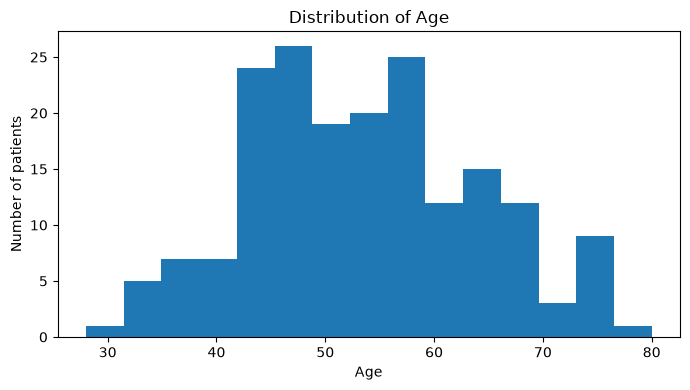

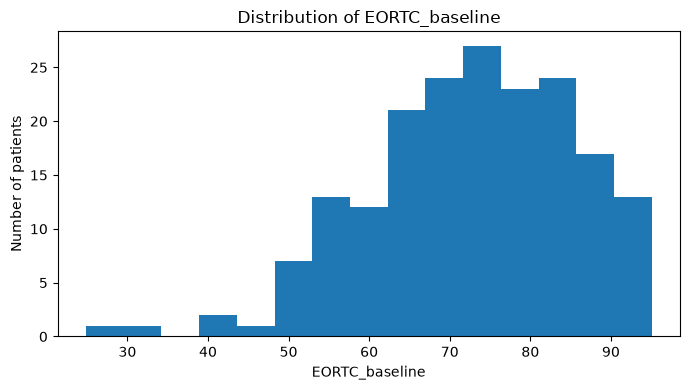

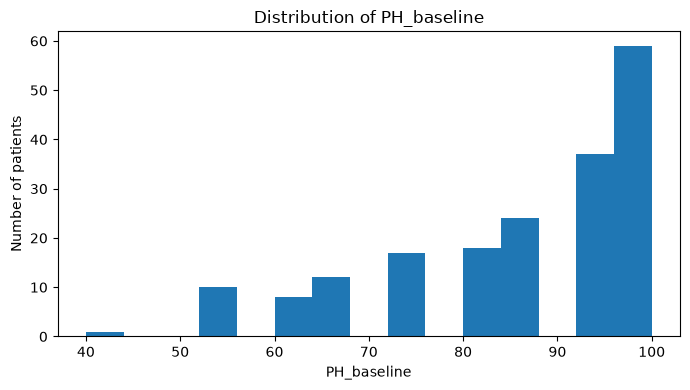

In [15]:
for column in numerical_features:

    plt.figure(figsize=(7, 4))

    plt.hist(
        df[column].dropna(),
        bins=15
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of patients")

    plt.tight_layout()
    plt.show()

In [16]:
categorical_features = [
    "Educational_level",
    "Occupational_status",
    "Children",
    "Marital_status",
    "TNM_stage",
    "HER2",
    "ECOG",
    "Surgery",
    "Axillary_lymphadenectomy",
    "Chemotherapy_regimen",
    "Radiotherapy",
    "Perceived_risk_recurrence",
]

for column in categorical_features:

    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)

    print(
        df[column].value_counts(dropna=False)
    )


Educational_level
Educational_level
Secondary or higher education    97
Other                            89
Name: count, dtype: int64

Occupational_status
Occupational_status
Not employed    98
Employed        88
Name: count, dtype: int64

Children
Children
2               82
0               36
1               36
> 2 children    31
NaN              1
Name: count, dtype: int64

Marital_status
Marital_status
Married/partnered    144
Single                42
Name: count, dtype: int64

TNM_stage
TNM_stage
II     111
I       60
III     15
Name: count, dtype: int64

HER2
HER2
Negative    142
Positive     44
Name: count, dtype: int64

ECOG
ECOG
0    139
1     44
2      3
Name: count, dtype: int64

Surgery
Surgery
BSC           99
Mastectomy    87
Name: count, dtype: int64

Axillary_lymphadenectomy
Axillary_lymphadenectomy
No     152
Yes     34
Name: count, dtype: int64

Chemotherapy_regimen
Chemotherapy_regimen
Taxane-based              131
Anthracycline-based        55
Name: count, dtype: i

In [17]:
targets = [
    "y_drop",
    "y_threshold",
]

for target in targets:

    print("\n" + "=" * 70)
    print(target)
    print("=" * 70)

    counts = (
        df[target]
        .value_counts()
        .sort_index()
    )

    percentages = (
        counts / len(df) * 100
    ).round(2)

    result = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    print(result)


y_drop
        Count  Percentage
y_drop                   
0         130       69.89
1          56       30.11

y_threshold
             Count  Percentage
y_threshold                   
0              131       70.43
1               55       29.57


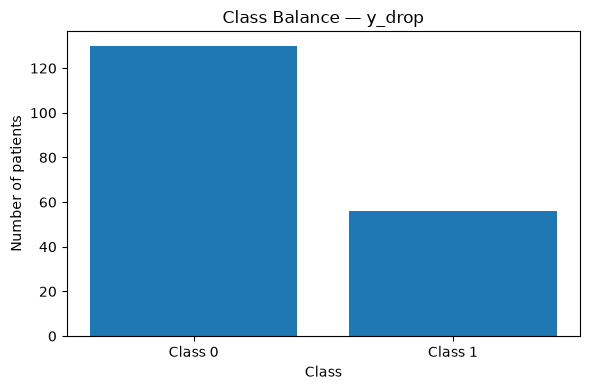

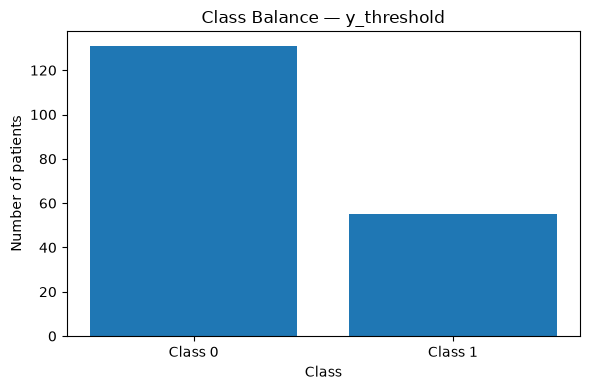

In [18]:
for target in targets:

    counts = (
        df[target]
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(6, 4))

    plt.bar(
        ["Class 0", "Class 1"],
        counts.values
    )

    plt.title(f"Class Balance — {target}")
    plt.xlabel("Class")
    plt.ylabel("Number of patients")

    plt.tight_layout()
    plt.show()

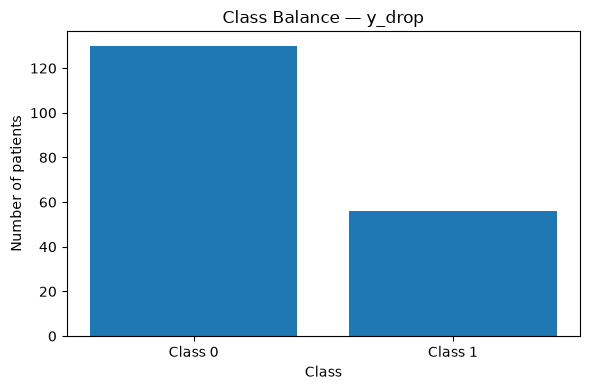

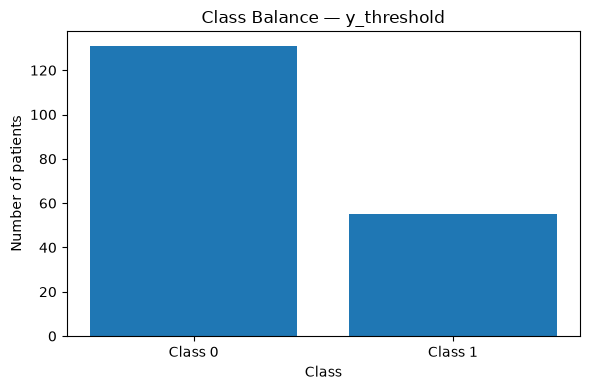

In [19]:
for target in targets:

    counts = (
        df[target]
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(6, 4))

    plt.bar(
        ["Class 0", "Class 1"],
        counts.values
    )

    plt.title(f"Class Balance — {target}")
    plt.xlabel("Class")
    plt.ylabel("Number of patients")

    plt.tight_layout()
    plt.show()

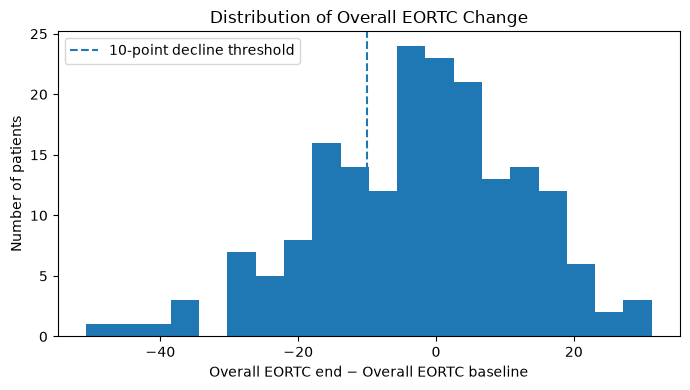

In [20]:
plt.figure(figsize=(7, 4))

plt.hist(
    df["y_drop_change"].dropna(),
    bins=20
)

plt.axvline(
    -10,
    linestyle="--",
    label="10-point decline threshold"
)

plt.title("Distribution of Overall EORTC Change")
plt.xlabel(
    "Overall EORTC end − Overall EORTC baseline"
)
plt.ylabel("Number of patients")

plt.legend()

plt.tight_layout()
plt.show()

<Figure size 700x400 with 0 Axes>

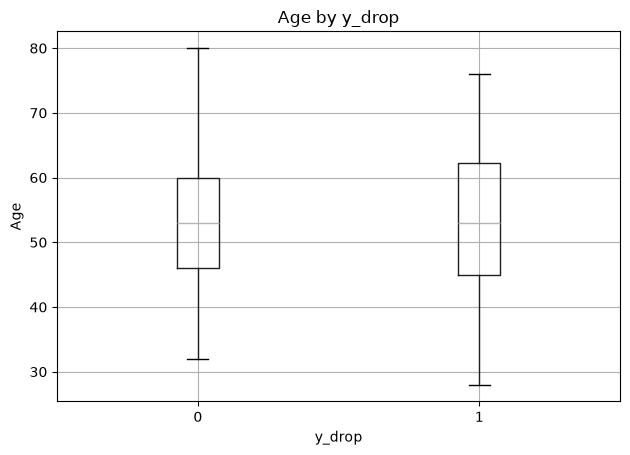

<Figure size 700x400 with 0 Axes>

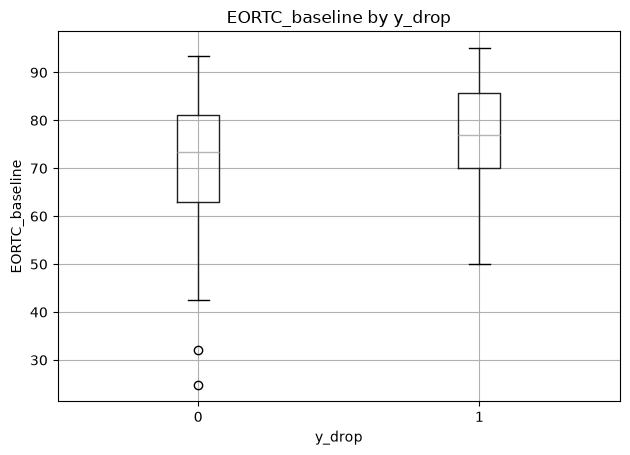

<Figure size 700x400 with 0 Axes>

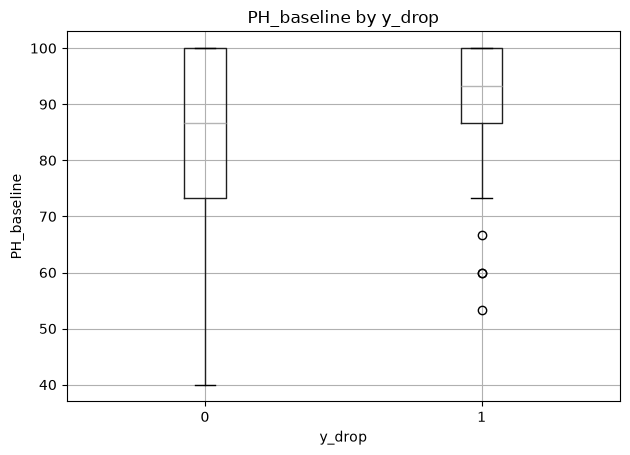

<Figure size 700x400 with 0 Axes>

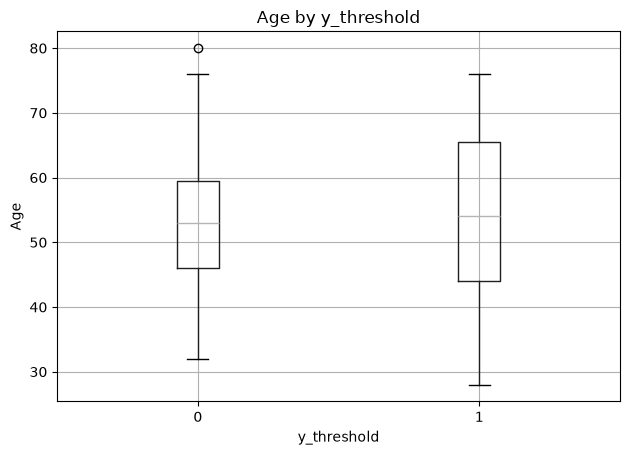

<Figure size 700x400 with 0 Axes>

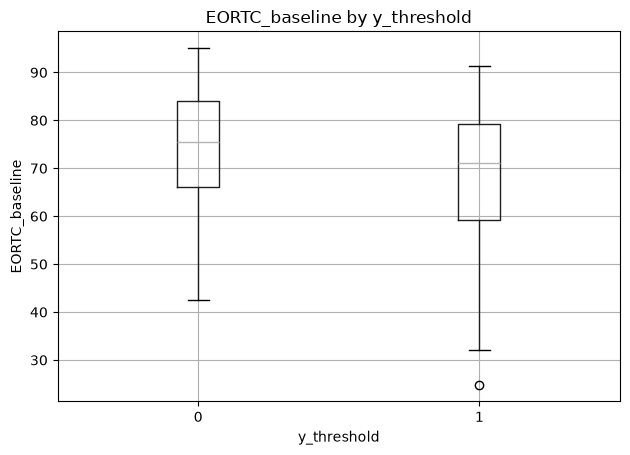

<Figure size 700x400 with 0 Axes>

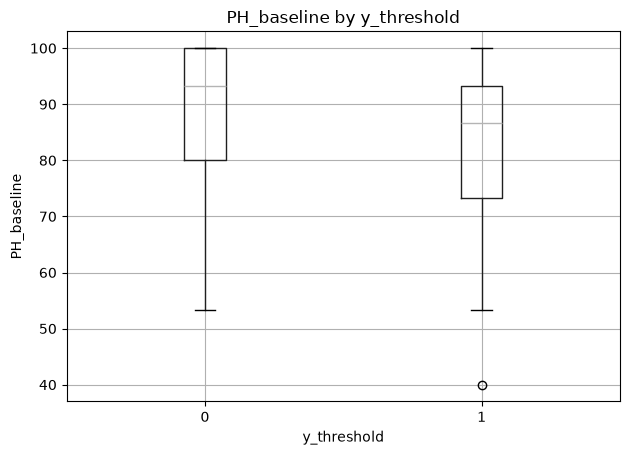

In [21]:
for target in targets:

    for feature in [
        "Age",
        "EORTC_baseline",
        "PH_baseline"
    ]:

        plt.figure(figsize=(7, 4))

        df.boxplot(
            column=feature,
            by=target
        )

        plt.title(
            f"{feature} by {target}"
        )

        plt.suptitle("")

        plt.xlabel(target)
        plt.ylabel(feature)

        plt.tight_layout()
        plt.show()

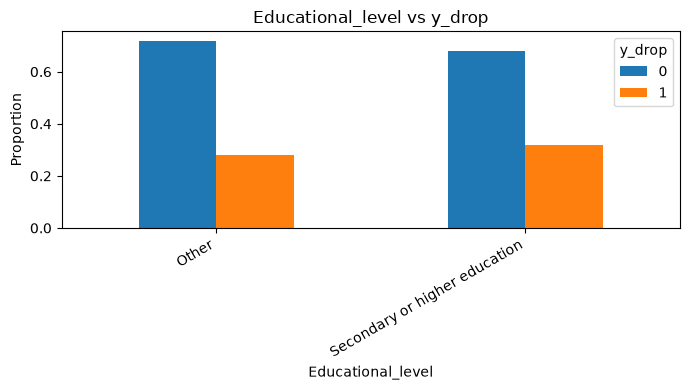

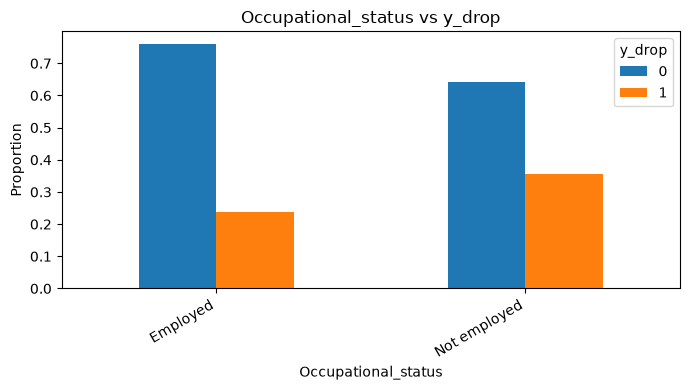

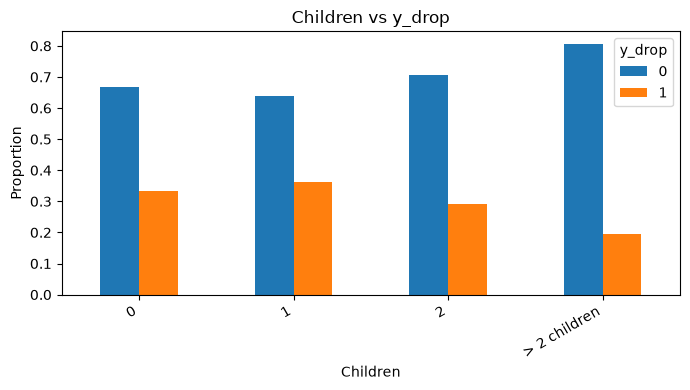

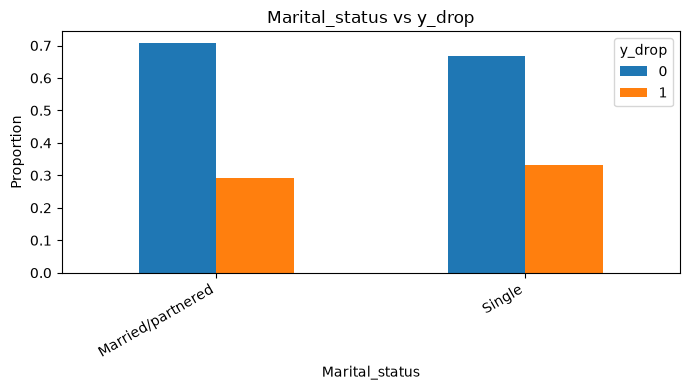

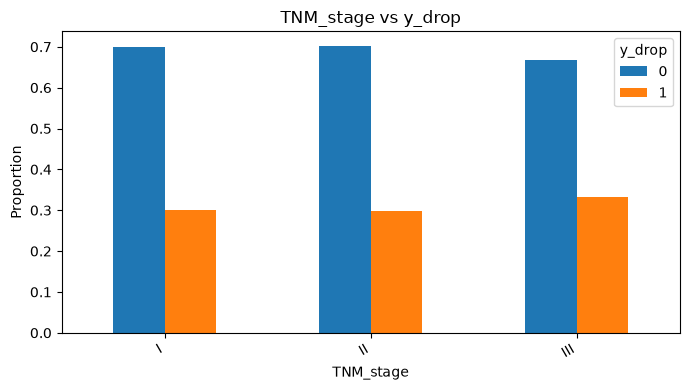

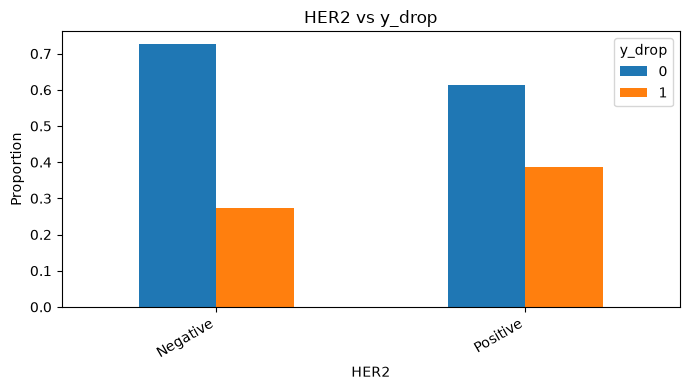

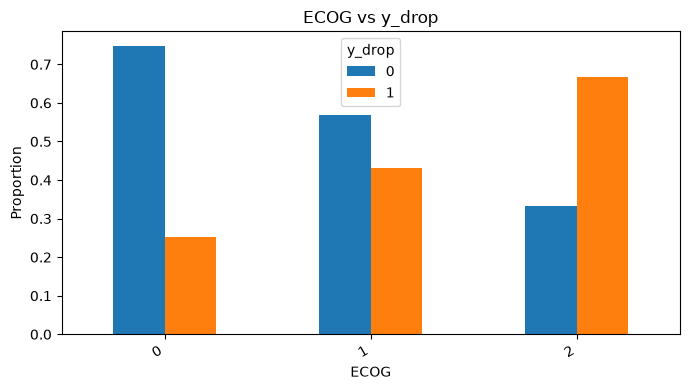

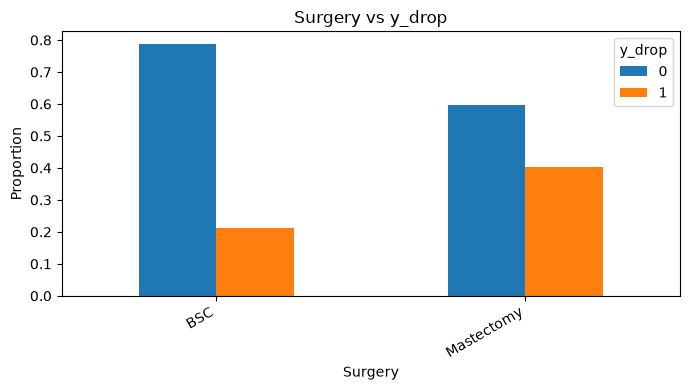

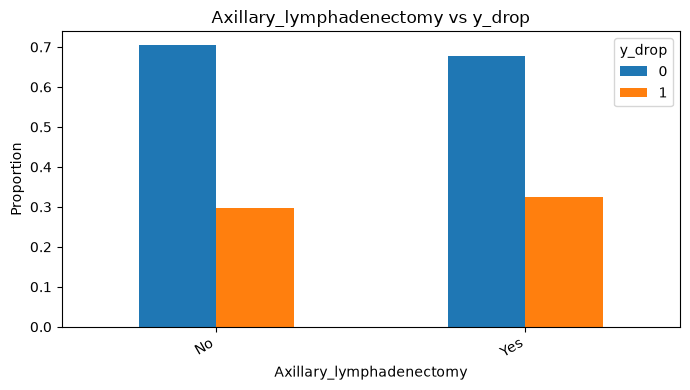

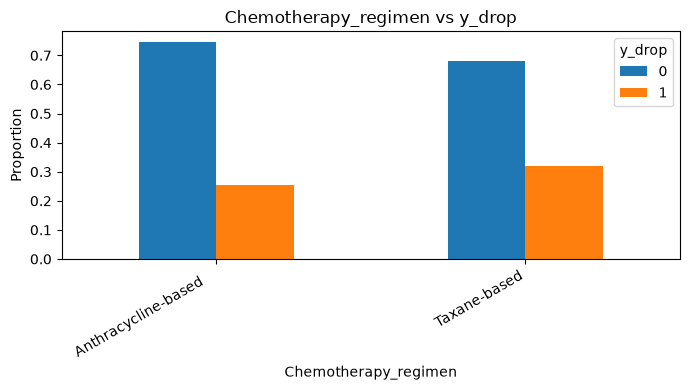

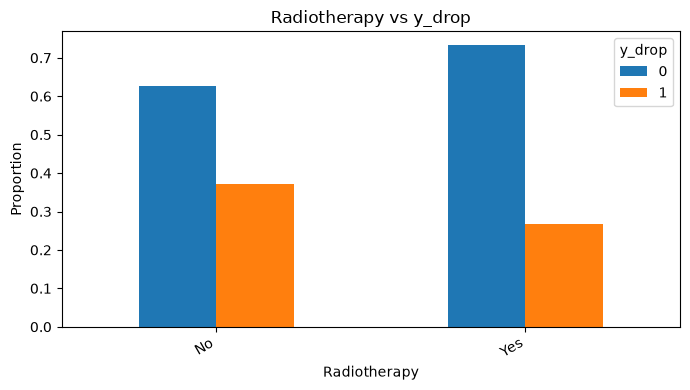

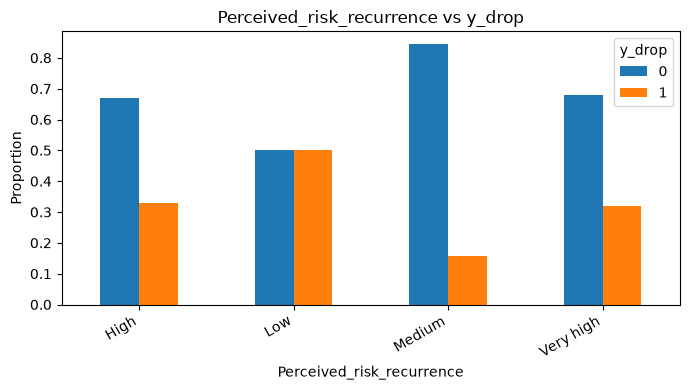

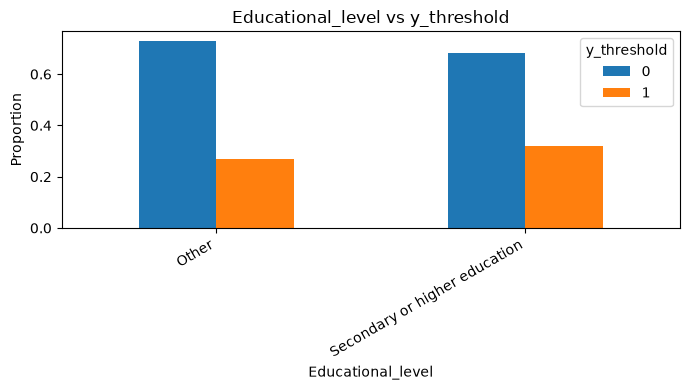

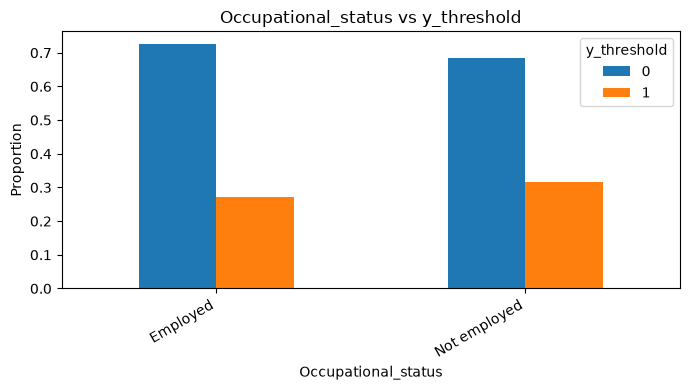

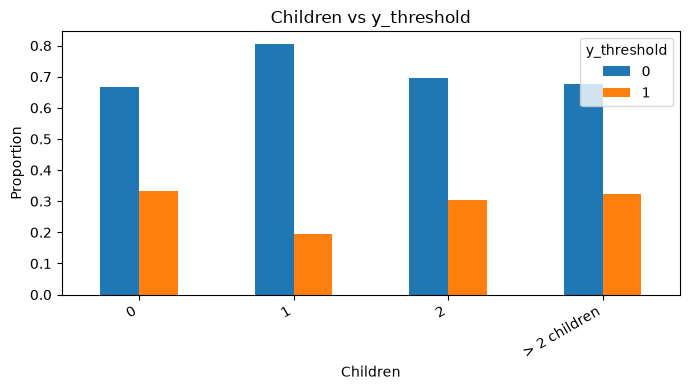

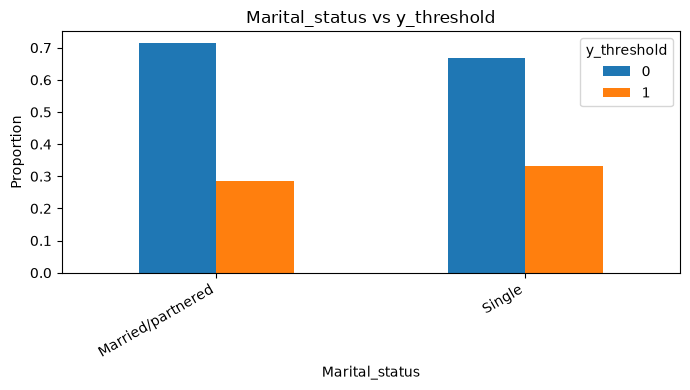

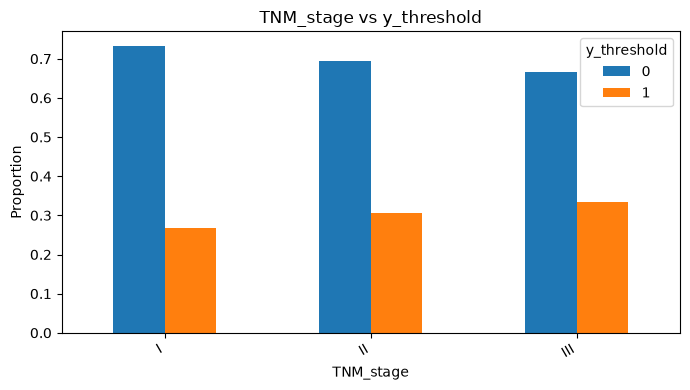

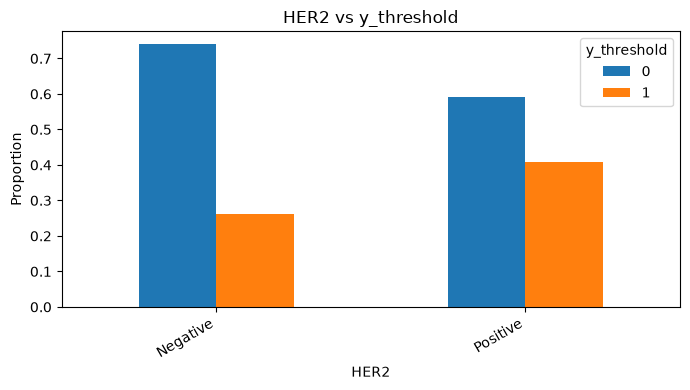

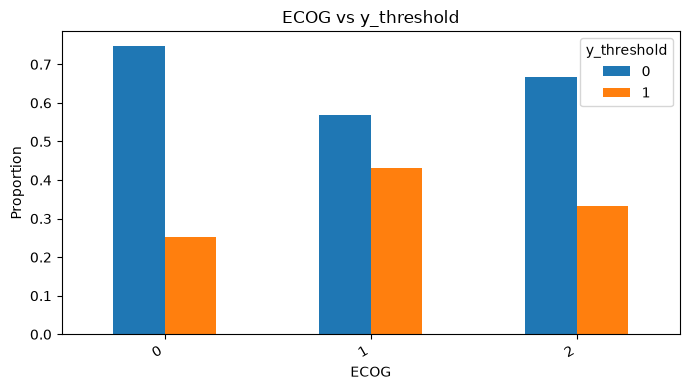

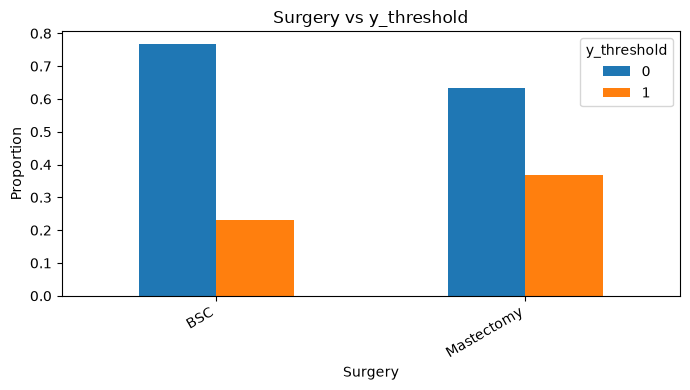

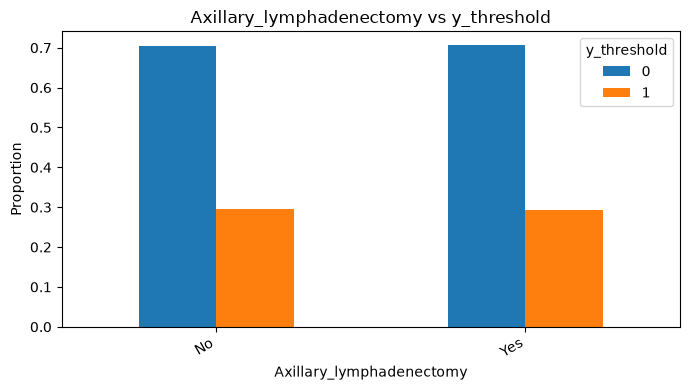

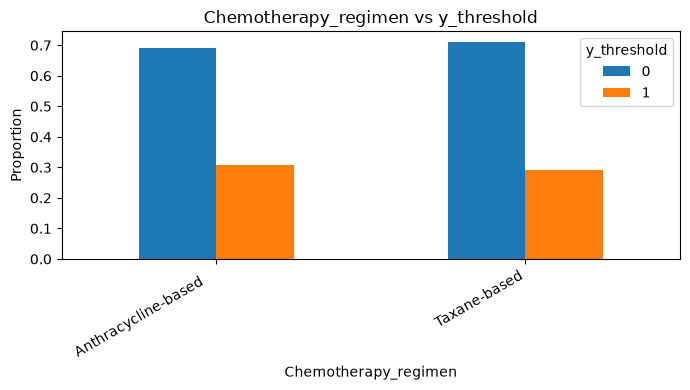

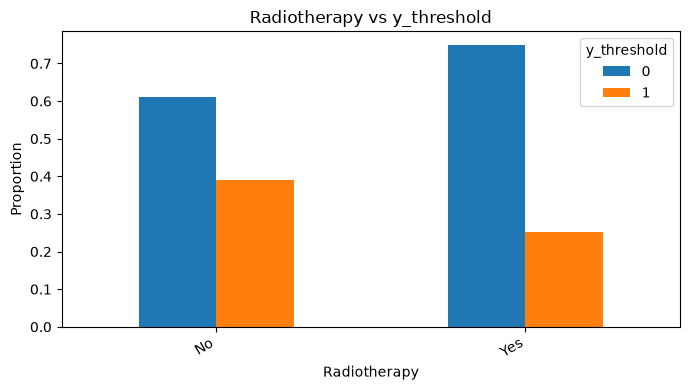

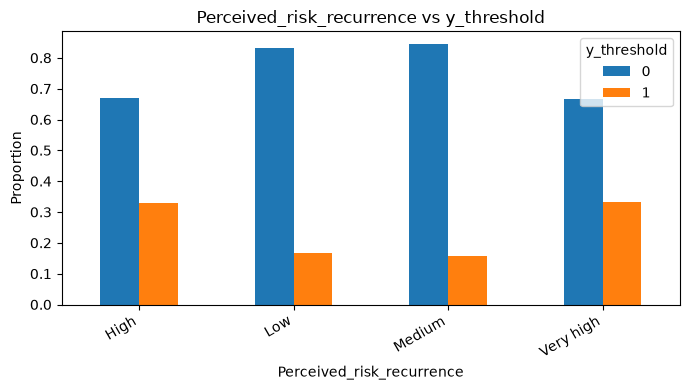

In [22]:
for target in targets:

    for feature in categorical_features:

        table = pd.crosstab(
            df[feature],
            df[target],
            normalize="index"
        )

        table.plot(
            kind="bar",
            figsize=(7, 4)
        )

        plt.title(
            f"{feature} vs {target}"
        )

        plt.xlabel(feature)
        plt.ylabel("Proportion")

        plt.xticks(
            rotation=30,
            ha="right"
        )

        plt.legend(
            title=target
        )

        plt.tight_layout()
        plt.show()

In [23]:
correlation_features = [
    "Age",
    "EORTC_baseline",
    "PH_baseline",
    "y_drop_change",
]

correlation_matrix = (
    df[correlation_features]
    .corr()
)

print(correlation_matrix)

                     Age  EORTC_baseline  PH_baseline  y_drop_change
Age             1.000000        0.082253    -0.003077      -0.063322
EORTC_baseline  0.082253        1.000000     0.655862      -0.398658
PH_baseline    -0.003077        0.655862     1.000000      -0.270510
y_drop_change  -0.063322       -0.398658    -0.270510       1.000000


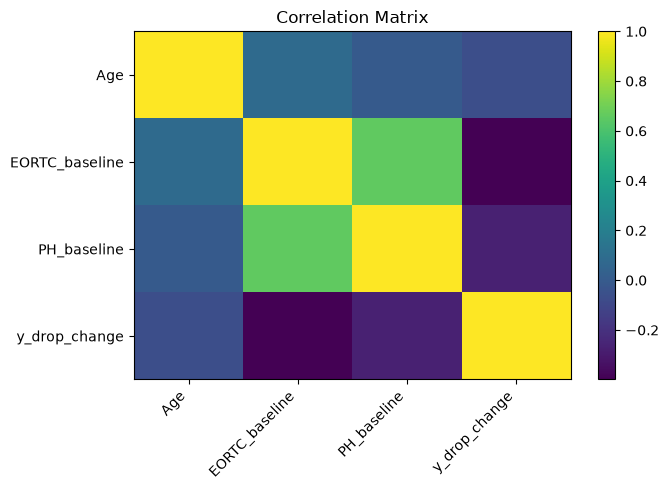

In [24]:
plt.figure(figsize=(7, 5))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## EDA Summary

- The final linked cohort contains 186 patients.
- `y_drop` contains 56 positive cases (30.11%) and 130 negative cases (69.89%).
- `y_threshold` contains 55 positive cases (29.57%) and 131 negative cases (70.43%).
- One missing value is present in `Children`.
- Missing values are retained and will be handled inside the preprocessing pipelines.
- Baseline numerical and categorical feature distributions were examined.
- The class balance of both prediction outcomes was examined.
- Overall EORTC change was examined using the -10 point deterioration threshold.
- Baseline demographic, clinical, treatment and QoL variables were compared descriptively across the two outcomes.
- EDA is descriptive and does not determine model selection or hyperparameter tuning.

Radiotherapy usually happens after chemotherapy - so we excluded it here in feature_groups 

Perceived_risk_recurrence is a potential psychological/baseline feature, but we have not established its exact collection timing from the available dataset documentation. So we'll keep it visible in the feature specification and document the timing limitation rather than silently pretending we know more than the data tells us.

In [27]:
m1 = get_preprocessor("M1")
m2 = get_preprocessor("M2")

print("M1 type:", type(m1))
print("M2 type:", type(m2))

print("\nFeature groups:")
print(get_feature_groups())

M1 type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
M2 type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>

Feature groups:
{'Age': 'demographic', 'Educational_level': 'demographic', 'Occupational_status': 'demographic', 'Children': 'demographic', 'Marital_status': 'demographic', 'TNM_stage': 'disease', 'HER2': 'disease', 'ECOG': 'disease', 'Surgery': 'treatment', 'Axillary_lymphadenectomy': 'treatment', 'Chemotherapy_regimen': 'treatment', 'Radiotherapy': 'treatment', 'EORTC_baseline': 'baseline_qol', 'Perceived_risk_recurrence': 'risk'}


In [29]:
import sys
from pathlib import Path

# Find project root
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import (
    load_dataset,
    get_feature_groups,
    get_preprocessor
)

print("Import successful!")

Import successful!


In [30]:
# Test y_drop

X, y = load_dataset("y_drop")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
for column in X.columns:
    print(column)

print("\nTarget distribution:")
print(y.value_counts())

print("\nFeature groups:")
print(get_feature_groups())

X shape: (186, 17)
y shape: (186,)

X columns:
QLQ_ID
Age
Educational_level
Occupational_status
Children
Marital_status
TNM_stage
HER2
ECOG
Surgery
Axillary_lymphadenectomy
Chemotherapy_regimen
Radiotherapy
EORTC_baseline
PH_baseline
Perceived_risk_recurrence
Overall_EORTC_baseline

Target distribution:
y_drop
0    130
1     56
Name: count, dtype: int64

Feature groups:
{'Age': 'demographics', 'Educational_level': 'demographics', 'Occupational_status': 'demographics', 'Children': 'demographics', 'Marital_status': 'demographics', 'TNM_stage': 'disease', 'HER2': 'disease', 'ECOG': 'disease', 'Surgery': 'treatment', 'Axillary_lymphadenectomy': 'treatment', 'Chemotherapy_regimen': 'treatment', 'Perceived_risk_recurrence': 'psychological', 'EORTC_baseline': 'baseline_qol', 'PH_baseline': 'baseline_qol'}


In [31]:
# Test y_threshold

X2, y2 = load_dataset("y_threshold")

print("X2 shape:", X2.shape)
print("y2 shape:", y2.shape)

print("\ny_threshold distribution:")
print(y2.value_counts())

X2 shape: (186, 17)
y2 shape: (186,)

y_threshold distribution:
y_threshold
0    131
1     55
Name: count, dtype: int64


In [32]:
print("X2 columns:")
for i, column in enumerate(X2.columns, 1):
    print(f"{i:2}. {column}")

X2 columns:
 1. QLQ_ID
 2. Age
 3. Educational_level
 4. Occupational_status
 5. Children
 6. Marital_status
 7. TNM_stage
 8. HER2
 9. ECOG
10. Surgery
11. Axillary_lymphadenectomy
12. Chemotherapy_regimen
13. Radiotherapy
14. EORTC_baseline
15. PH_baseline
16. Perceived_risk_recurrence
17. Overall_EORTC_baseline


In [40]:
import src.features as features

print("Loaded features.py from:")
print(features.__file__)

print("\nFunctions available:")
print([
    name for name in dir(features)
    if not name.startswith("_")
])

Loaded features.py from:
c:\Users\palla\OneDrive\Desktop\PESU Notes\3rd Year\ML\ML MiniProject\cancer-pro-prediction\src\features.py

Functions available:
['ColumnTransformer', 'DATA_PATH', 'FEATURE_GROUPS', 'KNNImputer', 'OneHotEncoder', 'PROJECT_ROOT', 'Path', 'Pipeline', 'SimpleImputer', 'StandardScaler', 'get_feature_groups', 'get_preprocessor', 'load_dataset', 'make_column_selector', 'np', 'pd']


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import (
    load_dataset,
    get_feature_groups,
    get_feature_columns,
    get_preprocessor
)

print("Imported successfully!")
print("Feature count:", len(get_feature_columns()))
print("Features:", get_feature_columns())

Imported successfully!
Feature count: 14
Features: ['Age', 'Educational_level', 'Occupational_status', 'Children', 'Marital_status', 'TNM_stage', 'HER2', 'ECOG', 'Surgery', 'Axillary_lymphadenectomy', 'Chemotherapy_regimen', 'Perceived_risk_recurrence', 'EORTC_baseline', 'PH_baseline']


In [2]:
X2, y2 = load_dataset("y_threshold")

print("X2 shape:", X2.shape)
print("y2 shape:", y2.shape)

X2 shape: (186, 14)
y2 shape: (186,)


In [3]:
# =========================================================
# TEST M1 AND M2 PREPROCESSING
# =========================================================

from sklearn.pipeline import Pipeline

# Load both outcomes
X_drop, y_drop = load_dataset("y_drop")
X_threshold, y_threshold = load_dataset("y_threshold")

# Get preprocessors
m1 = get_preprocessor("M1")
m2 = get_preprocessor("M2")

print("=" * 70)
print("FEATURE MATRIX")
print("=" * 70)

print("X_drop shape:", X_drop.shape)
print("X_threshold shape:", X_threshold.shape)

print("\nNumber of raw features:", X_drop.shape[1])

print("\nM1 type:", type(m1))
print("M2 type:", type(m2))


# =========================================================
# FIT/TRANSFORM M1
# =========================================================

X_drop_m1 = m1.fit_transform(X_drop)

print("\n" + "=" * 70)
print("M1 OUTPUT")
print("=" * 70)

print("Shape:", X_drop_m1.shape)
print("Type:", type(X_drop_m1))


# =========================================================
# FIT/TRANSFORM M2
# =========================================================

X_drop_m2 = m2.fit_transform(X_drop)

print("\n" + "=" * 70)
print("M2 OUTPUT")
print("=" * 70)

print("Shape:", X_drop_m2.shape)
print("Type:", type(X_drop_m2))

FEATURE MATRIX
X_drop shape: (186, 14)
X_threshold shape: (186, 14)

Number of raw features: 14

M1 type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
M2 type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>

M1 OUTPUT
Shape: (186, 29)
Type: <class 'numpy.ndarray'>

M2 OUTPUT
Shape: (186, 29)
Type: <class 'numpy.ndarray'>


In [4]:
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

GROUPS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "feature_groups.json"
)

with open(GROUPS_PATH, "r", encoding="utf-8") as f:
    groups = json.load(f)

print("Feature groups:")
print(json.dumps(groups, indent=4))

all_features = [
    feature
    for group in groups.values()
    for feature in group
]

print("\nTotal features:", len(all_features))
print("Unique features:", len(set(all_features)))

print("\nFeature count by group:")

for group, features in groups.items():
    print(f"{group}: {len(features)}")

Feature groups:
{
    "demographics": [
        "Age",
        "Educational_level",
        "Occupational_status",
        "Children",
        "Marital_status"
    ],
    "disease": [
        "TNM_stage",
        "HER2",
        "ECOG"
    ],
    "treatment": [
        "Surgery",
        "Axillary_lymphadenectomy",
        "Chemotherapy_regimen"
    ],
    "psychological": [
        "Perceived_risk_recurrence"
    ],
    "baseline_qol": [
        "EORTC_baseline",
        "PH_baseline"
    ]
}

Total features: 14
Unique features: 14

Feature count by group:
demographics: 5
disease: 3
treatment: 3
psychological: 1
baseline_qol: 2
